# Electricity

In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
%matplotlib inline

elec_par_file = '/work/hawkinslab/jfhawkin/SH-BART/data/vulcan/parquet/ELC2.CO2.BG.ann.smplst.mn.2019.parquet'

elec_df = gpd.read_parquet(elec_par_file)

# Create columns that assign decile numbers for each treatment variable
elec_df['treat_density'] = elec_df['d1a']
elec_df['treat_diversity'] = elec_df['d2b_e5mixa']

In [14]:
var_list = ['p_highschool','p_owner','pct_ao0','avg_hh_size',
 'med_dwelling_age','all_cdd', 'all_hdd', 'stc2erta', 'w_p_lowwag',
  'treat_density', 'treat_diversity']

In [15]:
# Compute correlation matrix
corr_matrix = elec_df.loc[:,var_list].corr(method="pearson")

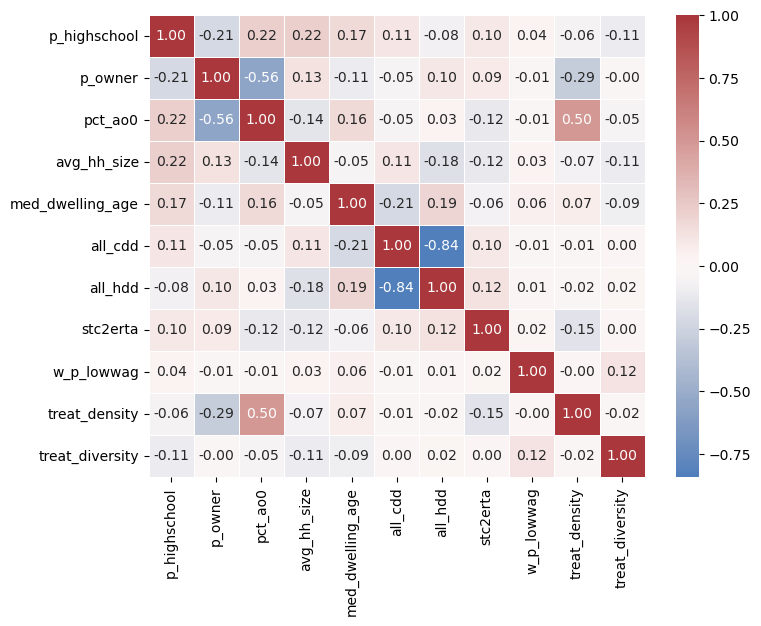

In [16]:
# Set up the figure size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, center=0)

# # Title
# plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.savefig("residential_heatmap.pdf", format='pdf')

In [62]:
imp_df = pd.read_csv('importance_electricity.csv')

In [63]:
imp_df.groupby(['Segment','Treatment', 'Feature']).agg(min_importance=('Importance', 'min'),
                                                        median_importance=('Importance', 'median'))

min_importance  median_importance
Segment Treatment Feature                                            
res     dens      all_cdd                 0.156078           0.234452
                  avg_hh_size            -0.005793           0.000968
                  med_dwelling_age        0.058710           0.405471
                  p_highschool           -0.002016           0.026460
                  pct_ao0                -0.002778           0.000501
                  stc2erta                0.059547           0.283531
                  w_p_lowwag             -0.005862          -0.004428
        div       all_cdd                 0.105326           0.124640
                  avg_hh_size            -0.003457          -0.000721
                  med_dwelling_age        0.318396           0.499273
                  p_highschool           -0.003240          -0.002113
                  pct_ao0                 0.013758           0.015582
                  stc2erta                0.089253           0.250381
                  w_p_lowwag             -0.000109           0.003576
tot     dens      all_cdd                 0.025074           0.066073
                  avg_hh_size            -0.015390           0.025472
                  med_dwelling_age        0.028099           0.066621
                  p_highschool           -0.005898          -0.001244
                  pct_ao0                -0.008592           0.063674
                  stc2erta                0.272564           0.300778
                  w_p_lowwag              0.049230           0.102755
        div       all_cdd                 0.011282           0.019633
                  avg_hh_size            -0.004405           0.002120
                  med_dwelling_age        0.062007           0.078028
                  p_highschool           -0.006522          -0.001733
                  pct_ao0                -0.001406           0.002392
                  stc2erta                0.307775           0.327524
                  w_p_lowwag              0.229625           0.428124

We can prioritize inclusion in the PS based on comparison of the sum of importance scores (relative contributions to R2).

**For residential CO2 and density:**
1. med_dwelling_age
2. stc2erta
3. all_cdd
4. p_highschool

Remaining are quite low (<0.05, or 0.01 per quintile):

5. pct_ao0 (strong correlation with density but not CO2 - interesting)
6. avg_hh_size
7. w_p_lowwag

**For residential CO2 and diversity:**

1. med_dwelling_age
2. stc2erta
3. all_cdd
4. pct_ao0

Remaining are quite low (<0.05, or 0.01 per quintile):

5. w_p_lowwag
6. avg_hh_size
7. p_highschool

**For total CO2 and density:**
1. stc2erta
2. w_p_lowwag
3. med_dwelling_age
4. all_cdd
5. pct_ao0
6. avg_hh_size
7. p_highschool

Remaining are quite low (<0.05, or 0.01 per quintile):

N/A

**For total CO2 and diversity:**
1. w_p_lowwag
2. stc2erta
3. med_dwelling_age
4. all_cdd

Remaining are quite low:

5. avg_hh_size
6. pct_ao0
7. p_highschool

In [105]:
df_agg = imp_df.groupby(['Segment', 'Treatment', 'Feature'], group_keys=False).agg(
    min_importance=('Importance', 'min'),
    median_importance=('Importance', 'median'),
    sum_importance=('Importance', 'sum')
).reset_index()  # Ensure Segment, Treatment, and Feature are columns

# Step 1: Compute the total sum_importance per (Segment, Treatment) group
group_order = df_agg.groupby(['Segment', 'Treatment'], as_index=False)['sum_importance'].sum()

# Step 2: Sort the groups by sum_importance in descending order
group_order = group_order.sort_values(by='sum_importance', ascending=False)[['Segment', 'Treatment']]

# Step 3: Merge sorted group order back into df_agg to preserve order
df_sorted = group_order.merge(df_agg, on=['Segment', 'Treatment']).sort_values(by=['Segment', 'Treatment', 'sum_importance'], ascending=[False, False, False])

print(df_sorted.set_index(['Segment', 'Treatment', 'Feature']))


                                    min_importance  median_importance  \
Segment Treatment Feature                                               
tot     div       w_p_lowwag              0.229625           0.428124   
                  stc2erta                0.307775           0.327524   
                  med_dwelling_age        0.062007           0.078028   
                  all_cdd                 0.011282           0.019633   
                  avg_hh_size            -0.004405           0.002120   
                  pct_ao0                -0.001406           0.002392   
                  p_highschool           -0.006522          -0.001733   
        dens      stc2erta                0.272564           0.300778   
                  w_p_lowwag              0.049230           0.102755   
                  med_dwelling_age        0.028099           0.066621   
                  all_cdd                 0.025074           0.066073   
                  pct_ao0                -0.008592 

# Transportation

In [8]:
tran_par_file = '/work/hawkinslab/jfhawkin/SH-BART/data/vulcan/parquet/vulcan_x_epa_onroad_mn_2015_climate.parquet'
transport_df = gpd.read_parquet(tran_par_file)

# Create columns that assign quintile numbers for each treatment variable
transport_df['treat_density'] = transport_df['d1a']
transport_df['treat_diversity'] = transport_df['d2b_e5mixa']
transport_df['treat_design'] = transport_df['d3a']
transport_df['d4a'] = transport_df['d4a'].fillna(0)
transport_df['treat_distance'] = transport_df['d4a']
transport_df['treat_destination'] = transport_df['d5ar']

In [9]:
transport_df.loc[:,['treat_design','treat_destination']].describe()

,treat_design,treat_destination
count,215788.000000,2.157880e+05
mean,15.817117,1.052141e+05
std,10.692151,1.541191e+05
min,0.000000,0.000000e+00
25%,5.697378,1.023175e+04
50%,15.701784,4.486100e+04
75%,23.393989,1.278932e+05
max,166.894521,1.220602e+06


In [10]:
var_list = ['p_highschool','p_owner','pct_ao0','avg_hh_size',
 'med_dwelling_age','totpop_cbsa', 'stc2erta', 'w_p_lowwag', 'gasprice',
  'treat_density', 'treat_diversity', 'treat_design', 'treat_distance', 'treat_destination']

transport_df.loc[:,var_list].fillna(method="ffill").isna().sum()

/tmp/ipykernel_3805830/4189347834.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  transport_df.loc[:,var_list].fillna(method="ffill").isna().sum()


p_highschool         0
p_owner              0
pct_ao0              0
avg_hh_size          0
med_dwelling_age     0
totpop_cbsa          0
stc2erta             0
w_p_lowwag           0
gasprice             0
treat_density        0
treat_diversity      0
treat_design         0
treat_distance       0
treat_destination    0
dtype: int64

In [11]:
# Compute correlation matrix
corr_matrix = transport_df.loc[:,var_list].corr(method="pearson")

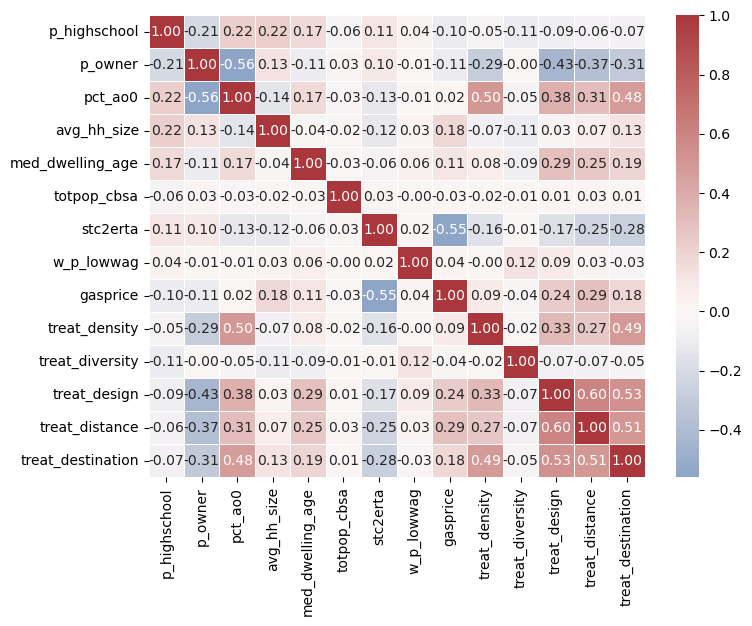

In [12]:
# Set up the figure size
plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".2f", linewidths=0.5, center=0)

# Title
# plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.savefig("transport_heatmap.pdf", format='pdf')

In [111]:
imp_df = pd.read_csv('importance_transport.csv')

In [112]:
imp_df.groupby(['Segment','Treatment', 'Feature']).agg(min_importance=('Importance', 'min'),
                                                        median_importance=('Importance', 'median'))

min_importance  median_importance
Segment Treatment Feature                                            
res     dens      avg_hh_size            -0.010312           0.035532
                  gasprice               -0.000847           0.018609
                  med_dwelling_age        0.198734           0.443779
                  p_highschool            0.009484           0.016312
                  pct_ao0                -0.000063           0.036029
                  stc2erta               -0.001662           0.019989
                  totpop_cbsa            -0.003927           0.003210
                  w_p_lowwag              0.043684           0.054594
transpo des       avg_hh_size            -0.002414           0.000501
                  gasprice                0.000015           0.073390
                  med_dwelling_age        0.091620           0.355576
                  p_highschool           -0.010600           0.002276
                  pct_ao0                -0.006524           0.017033
                  stc2erta                0.004752           0.064382
                  totpop_cbsa            -0.002219           0.003494
                  w_p_lowwag              0.086373           0.142759
        dest      avg_hh_size            -0.005423           0.000721
                  gasprice                0.005334           0.015145
                  med_dwelling_age        0.295712           0.560331
                  p_highschool           -0.012642           0.004428
                  pct_ao0                 0.027529           0.049780
                  stc2erta               -0.004479           0.002128
                  totpop_cbsa            -0.005627          -0.001841
                  w_p_lowwag              0.069799           0.127331
        dist      avg_hh_size             0.005356           0.007577
                  gasprice                0.000181           0.029340
                  med_dwelling_age        0.423236           0.518872
                  p_highschool           -0.008061          -0.004033
                  pct_ao0                 0.078597           0.105255
                  stc2erta               -0.001950           0.007747
                  totpop_cbsa            -0.003079          -0.001991
                  w_p_lowwag              0.131757           0.149919
        div       avg_hh_size            -0.010393           0.002891
                  gasprice                0.007445           0.017012
                  med_dwelling_age        0.239140           0.430343
                  p_highschool            0.000986           0.025642
                  pct_ao0                 0.073675           0.103358
                  stc2erta               -0.000043           0.005344
                  totpop_cbsa            -0.006846           0.000266
                  w_p_lowwag              0.092815           0.238059

We can prioritize inclusion in the PS based on comparison of the minimum and median importance scores (relative contributions to R2).

**For transport CO2 and density:**
1. med_dwelling_age
2. w_p_lowwag
3. gasprice
4. pct_ao0
5. stc2erta
6. avg_hh_size
7. p_highschool

Remaining are quite low (<0.05, or 0.01 per quintile):

8. totpop_cbsa

**For transport CO2 and design:**
1. med_dwelling_age
2. w_p_lowwag
3. stc2erta
4. gasprice
5. pct_ao0
6. p_highschool
7. avg_hh_size

Remaining are quite low (<0.05, or 0.01 per quintile):

8. totpop_cbsa

**For transport CO2 and destination:**
1. med_dwelling_age
2. w_p_lowwag
3. pct_ao0
4. stc2erta
5. gasprice

Remaining are quite low (<0.05, or 0.01 per quintile):

6. avg_hh_size
7. p_highschool
8. totpop_cbsa

**For transport CO2 and distance to transit:**
1. med_dwelling_age
2. w_p_lowwag
3. pct_ao0
4. gasprice

Remaining are quite low (<0.05, or 0.01 per quintile):

5. stc2erta
6. avg_hh_size
7. totpop_cbsa
8. p_highschool

**For transport CO2 and diversity:**
1. med_dwelling_age
2. w_p_lowwag
3. pct_ao0
4. gasprice
5. p_highschool

Remaining are quite low (<0.05, or 0.01 per quintile):

6. stc2erta
7. totpop_cbsa
8. avg_hh_size

In [113]:
df_agg = imp_df.groupby(['Segment', 'Treatment', 'Feature'], group_keys=False).agg(
    min_importance=('Importance', 'min'),
    median_importance=('Importance', 'median'),
    sum_importance=('Importance', 'sum')
).reset_index()  # Ensure Segment, Treatment, and Feature are columns

# Step 1: Compute the total sum_importance per (Segment, Treatment) group
group_order = df_agg.groupby(['Segment', 'Treatment'], as_index=False)['sum_importance'].sum()

# Step 2: Sort the groups by sum_importance in descending order
group_order = group_order.sort_values(by='sum_importance', ascending=False)[['Segment', 'Treatment']]

# Step 3: Merge sorted group order back into df_agg to preserve order
df_sorted = group_order.merge(df_agg, on=['Segment', 'Treatment']).sort_values(by=['Segment', 'Treatment', 'sum_importance'], ascending=[False, False, False])

print(df_sorted.set_index(['Segment', 'Treatment', 'Feature']))

                                    min_importance  median_importance  \
Segment Treatment Feature                                               
transpo div       med_dwelling_age        0.239140           0.430343   
                  w_p_lowwag              0.092815           0.238059   
                  pct_ao0                 0.073675           0.103358   
                  gasprice                0.007445           0.017012   
                  p_highschool            0.000986           0.025642   
                  stc2erta               -0.000043           0.005344   
                  totpop_cbsa            -0.006846           0.000266   
                  avg_hh_size            -0.010393           0.002891   
        dist      med_dwelling_age        0.423236           0.518872   
                  w_p_lowwag              0.131757           0.149919   
                  pct_ao0                 0.078597           0.105255   
                  gasprice                0.000181 

# Residential Energy

In [ ]:
# plt.title("Pearson Correlation Heatmap", fontsize=14)
plt.savefig("transport_heatmap.pdf", format='pdf')

In [2]:
imp_df = pd.read_csv('importance_residential.csv')

In [3]:
imp_df.groupby(['Segment','Treatment', 'Feature']).agg(min_importance=('Importance', 'min'),
                                                        median_importance=('Importance', 'median'))

min_importance  median_importance
Segment    Treatment Feature                                            
res_energy dens      all_cdd                 0.663905           0.853793
                     avg_hh_size            -0.006465           0.001496
                     med_dwelling_age       -0.008015          -0.000407
                     p_highschool            0.000970           0.017429
                     pct_ao0                -0.002407           0.004142
                     stc2erta               -0.000795           0.015720
                     w_p_lowwag             -0.006520           0.001679
           div       all_cdd                 0.829467           0.859770
                     avg_hh_size            -0.006445          -0.000612
                     med_dwelling_age       -0.003002           0.001104
                     p_highschool            0.004711           0.022662
                     pct_ao0                -0.006095          -0.001006
                     stc2erta               -0.000625           0.004951
                     w_p_lowwag              0.003242           0.012397

In [4]:
df_agg = imp_df.groupby(['Segment', 'Treatment', 'Feature'], group_keys=False).agg(
    min_importance=('Importance', 'min'),
    median_importance=('Importance', 'median'),
    sum_importance=('Importance', 'sum')
).reset_index()  # Ensure Segment, Treatment, and Feature are columns

# Step 1: Compute the total sum_importance per (Segment, Treatment) group
group_order = df_agg.groupby(['Segment', 'Treatment'], as_index=False)['sum_importance'].sum()

# Step 2: Sort the groups by sum_importance in descending order
group_order = group_order.sort_values(by='sum_importance', ascending=False)[['Segment', 'Treatment']]

# Step 3: Merge sorted group order back into df_agg to preserve order
df_sorted = group_order.merge(df_agg, on=['Segment', 'Treatment']).sort_values(by=['Segment', 'Treatment', 'sum_importance'], ascending=[False, False, False])

print(df_sorted.set_index(['Segment', 'Treatment', 'Feature']))

                                       min_importance  median_importance  \
Segment    Treatment Feature                                               
res_energy div       all_cdd                 0.829467           0.859770   
                     p_highschool            0.004711           0.022662   
                     w_p_lowwag              0.003242           0.012397   
                     stc2erta               -0.000625           0.004951   
                     med_dwelling_age       -0.003002           0.001104   
                     pct_ao0                -0.006095          -0.001006   
                     avg_hh_size            -0.006445          -0.000612   
           dens      all_cdd                 0.663905           0.853793   
                     stc2erta               -0.000795           0.015720   
                     p_highschool            0.000970           0.017429   
                     pct_ao0                -0.002407           0.004142   
            

We can prioritize inclusion in the PS based on comparison of the minimum and median importance scores (relative contributions to R2).

**For residential CO2 and density:**
1. all_cdd
2. stc2erta
3. p_highschool
4. pct_ao0

Remaining are quite low (<0.05, or 0.01 per quintile):
5. med_dwelling_age
6. w_p_lowwag
7. avg_hh_size

**For residential CO2 and diversity:**
1. all_cdd
2. p_highschool
3. w_p_lowwag
4. stc2erta

Remaining are quite low (<0.05, or 0.01 per quintile):
5. med_dwelling_age
6. avg_hh_size
7. pct_ao0
